In [2]:
%pip install pandas matplotlib trino tzlocal --quiet

Note: you may need to restart the kernel to use updated packages.


In [40]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from trino.dbapi import connect
from trino.auth import BasicAuthentication, OAuth2Authentication

TRINO_HOST = "turing-embedded-data-science-fte-mode.trino.galaxy.starburst.io"
TRINO_CATALOG = "trainline_data"

# Reusable plotting standards for this notebook.
PLOT_COLORS = {
    "primary": "#1F4E79",
    "secondary": "#4C78A8",
    "accent": "#F58518",
    "success": "#2E8B57",
    "danger": "#C73E1D",
    "neutral": "#6B7280",
    "phase1": "#A8DADC",
    "phase2": "#FBC4AB",
}

DEFAULT_TEST_MILESTONES = [
    (pd.Timestamp("2026-05-26"), "Upweight 2x"),
    (pd.Timestamp("2026-06-09"), "Downweight 0%"),
    (pd.Timestamp("2026-06-23"), "Restore normal"),
]

DEFAULT_SPEND_WINDOWS = [
    ("pre (14d before upweight)", "2026-05-12", "2026-05-25"),
    ("phase1 upweight", "2026-05-26", "2026-06-08"),
    ("phase2 downweight", "2026-06-09", "2026-06-22"),
    ("post restore", "2026-06-23", "2026-07-06"),
]


def set_plot_style():
    plt.style.use("default")
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "#D1D5DB",
            "axes.grid": True,
            "grid.color": "#E5E7EB",
            "grid.linestyle": "-",
            "grid.alpha": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.titleweight": "bold",
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.frameon": False,
            "lines.linewidth": 1.8,
        }
    )


def style_axis(ax, title=None, ylabel=None, xlabel=None):
    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    ax.grid(True)


def get_test_milestones(cfg=None):
    if cfg is None:
        return DEFAULT_TEST_MILESTONES

    required = {"phase1_start", "phase2_start", "post_start"}
    if not required.issubset(set(cfg.keys())):
        return DEFAULT_TEST_MILESTONES

    return [
        (pd.Timestamp(cfg["phase1_start"]), "Upweight 2x"),
        (pd.Timestamp(cfg["phase2_start"]), "Downweight 0%"),
        (pd.Timestamp(cfg["post_start"]), "Restore normal"),
    ]


def add_test_phase_markers(ax, milestones=None, date_min=None, date_max=None, y_pos=0.94):
    milestones = milestones if milestones is not None else DEFAULT_TEST_MILESTONES
    y_min, y_max = ax.get_ylim()
    y_txt = y_min + (y_max - y_min) * y_pos

    for d, label in milestones:
        if (date_min is not None and d < date_min) or (date_max is not None and d > date_max):
            continue
        ax.axvline(d, color="#111827", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(d, y_txt, label, rotation=90, va="top", ha="right", fontsize=8, color="#111827")


def add_phase_spans(ax, cfg):
    p1_s, p1_e = pd.to_datetime(cfg["phase1_start"]), pd.to_datetime(cfg["phase1_end"])
    p2_s, p2_e = pd.to_datetime(cfg["phase2_start"]), pd.to_datetime(cfg["phase2_end"])
    ax.axvspan(p1_s, p1_e, alpha=0.14, color=PLOT_COLORS["phase1"])
    ax.axvspan(p2_s, p2_e, alpha=0.14, color=PLOT_COLORS["phase2"])


def add_rolling_columns(df, value_cols, window=7, min_periods=1, suffix="ma"):
    out = df.copy()
    for c in value_cols:
        out[f"{c}_{suffix}{window}"] = out[c].rolling(window, min_periods=min_periods).mean()
    return out


def filter_date_window(df, date_col, start, end):
    m = (df[date_col] >= pd.Timestamp(start)) & (df[date_col] <= pd.Timestamp(end))
    return df.loc[m]


def summarize_windows(df, date_col, metric_cols, windows):
    rows = []
    for label, start, end in windows:
        d = filter_date_window(df, date_col, start, end)
        row = {"window": label}
        for metric in metric_cols:
            row[f"avg_{metric}"] = d[metric].mean()
        rows.append(row)
    return pd.DataFrame(rows)


set_plot_style()

private_path = Path("private.json")

if private_path.exists():
    creds = json.loads(private_path.read_text())
    db_user = creds["email"]
    db_password = creds["password"]
    auth = BasicAuthentication(db_user, db_password)
else:
    db_user = os.getenv("db_user") or os.getenv("TRINO_USER")
    db_password = os.getenv("db_password") or os.getenv("TRINO_PASSWORD")

    if db_user and db_password:
        auth = BasicAuthentication(db_user, db_password)
    else:
        # Fall back to OAuth if no private.json / password creds are available
        db_user = db_user or os.getenv("EMAIL") or os.getenv("USER")
        auth = OAuth2Authentication()

conn = locals().get(
    "conn",
    connect(
        auth=auth,
        http_scheme="https",
        host=TRINO_HOST,
        port=443,
        user=db_user,
        catalog=TRINO_CATALOG,
    ),
)

## Meta Spend — Daily Spend Trend

This query pulls daily **UK Meta (Facebook/Paid Social) spend** from `marketing_yield`, going back to November 2025 so we have a long enough pre-period to see seasonality. We then filter to April 2026 onwards for charting.

`original_attribution = FALSE` means we're using Trainline's re-attributed view (redistributing unknown cookie-consent traffic), which is the standard way to compare spend vs outcomes.

The chart plots the raw daily spend (faint line) alongside a **7-day moving average** (bold line) to smooth out day-of-week noise. Vertical dashed lines mark the three test milestones: Upweight 2x, Downweight 0%, and Restore normal.

In [50]:


daily_meta_spend = """
SELECT
    DATE(activity_date) as activity_date,
    channel_0,
    channel_1,
    channel_2,
    region,
    SUM(marketing_spend_gbp) AS spend_gbp,
    SUM(marketing_spend_eur) AS spend_eur
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
    AND DATE(activity_date) >= DATE '2025-11-05'
    AND region = 'United Kingdom'
    AND channel_0 = 'Web - Paid Social'
    AND channel_2 = 'Facebook'
GROUP BY 1,2,3,4,5
ORDER BY 1
"""

meta_spend_df = pd.read_sql(daily_meta_spend, conn)

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/1453848607.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  meta_spend_df = pd.read_sql(daily_meta_spend, conn)


In [51]:
meta_spend_df["activity_date"] = pd.to_datetime(meta_spend_df["activity_date"])
meta_spend_df = meta_spend_df[meta_spend_df['activity_date'] >= '2026-04-01']
meta_spend_df

,activity_date,channel_0,channel_1,channel_2,region,spend_gbp,spend_eur
147,2026-04-01,Web - Paid Social,Paid Social,Facebook,United Kingdom,2015.730000,2313.352534
148,2026-04-02,Web - Paid Social,Paid Social,Facebook,United Kingdom,1969.030000,2254.539350
149,2026-04-03,Web - Paid Social,Paid Social,Facebook,United Kingdom,1724.500000,1976.656390
150,2026-04-04,Web - Paid Social,Paid Social,Facebook,United Kingdom,1895.089999,2171.015103
151,2026-04-05,Web - Paid Social,Paid Social,Facebook,United Kingdom,2087.120000,2391.004672
...,...,...,...,...,...,...,...
219,2026-06-12,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,0.000000
220,2026-06-13,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,0.000000
221,2026-06-14,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,0.000000
222,2026-06-15,Web - Paid Social,Paid Social,Facebook,United Kingdom,0.000000,0.000000


,window,avg_spend_gbp,avg_spend_eur
0,pre (14d before upweight),1855.400714,2139.050095
1,phase1 upweight,3653.005714,4222.495184
2,phase2 downweight,0.000000,0.000000
3,post restore,NaN,NaN


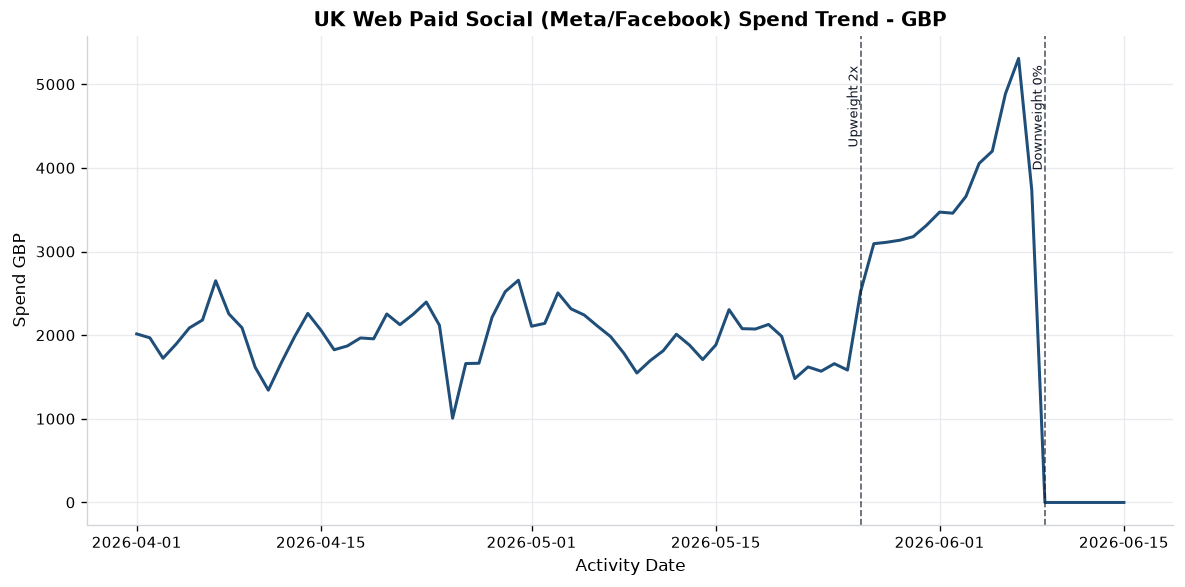

In [53]:
# Paid Social trend view using reusable plotting standards.
plot_df = meta_spend_df.copy()
plot_df["activity_date"] = pd.to_datetime(plot_df["activity_date"])
plot_df = plot_df.sort_values("activity_date")
plot_df = add_rolling_columns(plot_df, ["spend_gbp", "spend_eur"], window=7, suffix="ma")

fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharex=True)

ax.plot(
    plot_df["activity_date"],
    plot_df["spend_gbp"],
    color=PLOT_COLORS["secondary"],
    alpha=0.35,
    linewidth=1.0,
    label="Daily GBP",
)
ax.plot(
    plot_df["activity_date"],
    plot_df["spend_gbp_ma7"],
    color=PLOT_COLORS["primary"],
    linewidth=2.4,
    label="7-day MA GBP",
)

style_axis(ax, title="UK Web Paid Social (Meta/Facebook) Spend Trend - GBP", ylabel="Spend GBP", xlabel="Activity Date")

add_test_phase_markers(
    ax,
    milestones=get_test_milestones(),
    date_min=plot_df["activity_date"].min(),
    date_max=plot_df["activity_date"].max(),
)

plt.tight_layout()

window_summary = summarize_windows(
    df=plot_df,
    date_col="activity_date",
    metric_cols=["spend_gbp", "spend_eur"],
    windows=DEFAULT_SPEND_WINDOWS,
)

window_summary

## Marketing Orders Table

Placeholder for any order-level queries using `de_dwh_lf.marketing_orders` — useful if you want to look at NTS scaled for cookie consent (as Tom did for Italy), or to inspect reacquisition rates. Tom couldn't use this for the Italy analysis due to a bug with missing "days since last order" data, but it should be available for the UK Meta test.

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Open the following URL in browser for the external authentication:
https://turing-embedded-data-science-fte-mode.trino.galaxy.starburst.io/oauth/v2/tokenexchange/initiate/e6e6a5cf2a8f6da14c1e61178d9d60e5ef09c2b6a7b479a0923628262c9a1693
Cookie-consent-scaled NTS phase summary:


,phase,raw_nts_gbp_sum,raw_nts_gbp_mean,raw_nts_gbp_median,scaled_nts_gbp_sum,scaled_nts_gbp_mean,scaled_nts_gbp_median,days
0,phase1_plus28k,1.061389e+07,758135.004089,786919.090611,1.122801e+07,802000.864487,832021.764843,14
1,phase2_minus28k,6.486726e+06,720747.305319,770873.524528,6.859322e+06,762146.898005,814346.361879,9
2,pre,9.360350e+06,668596.407333,729781.409194,9.883835e+06,705988.204544,770775.945955,14


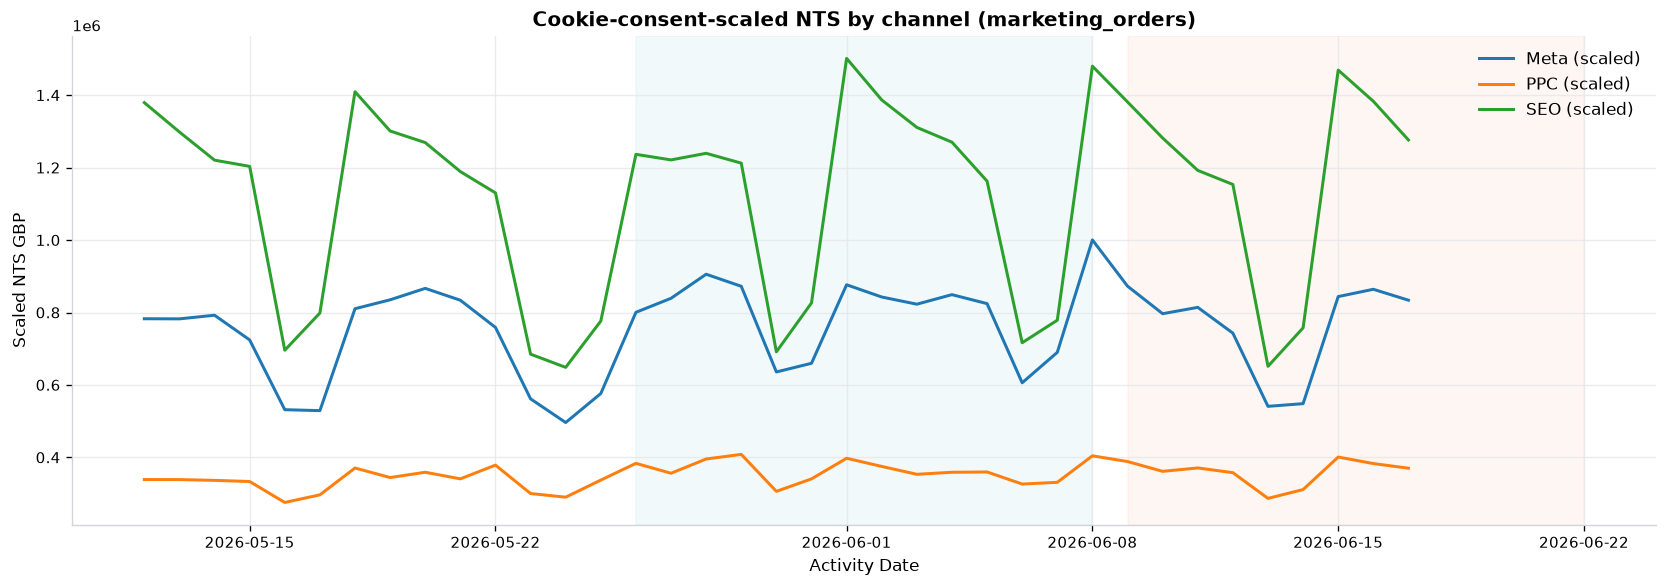

In [54]:
# Cookie-consent-scaled NTS from marketing_orders (Tom's Italy approach, adapted for UK Meta)
#
# marketing_yield NTS is based on attributed orders only.
# marketing_orders contains ALL orders (including unknown/unattributed), which lets us
# scale channel NTS upwards to account for cookie consent gaps — the same technique
# Tom used for Italy. The proportion of "Unknown" channel NTS tells us how much
# attribution is missing each day, and we divide by (1 - that proportion) to scale up.

q_scaled_nts = """
WITH unknown_channel_nts AS (
    SELECT
        DATE(activity_date)                                          AS activity_date,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0))            AS unknown_nts,
        SUM(net_sales_gbp)                                           AS total_nts,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0))
            / NULLIF(SUM(net_sales_gbp), 0)                         AS proportion_nts_unknown
    FROM de_dwh_lf.marketing_orders
    WHERE region = 'United Kingdom'
      AND DATE(activity_date) >= DATE '2026-05-12'
    GROUP BY 1
),
marketing_channel_nts AS (
    SELECT
        DATE(activity_date)  AS activity_date,
        channel_0,
        channel_1,
        channel_2,
        SUM(net_sales_gbp)   AS nts_gbp
    FROM de_dwh_lf.marketing_orders
    WHERE region = 'United Kingdom'
      AND DATE(activity_date) >= DATE '2026-05-12'
      AND channel_0 != 'Unknown'
    GROUP BY 1, 2, 3, 4
)
SELECT
    mcn.activity_date,
    mcn.channel_0,
    mcn.channel_1,
    mcn.channel_2,
    mcn.nts_gbp                                              AS raw_nts_gbp,
    mcn.nts_gbp / NULLIF(1 - ucn.proportion_nts_unknown, 0) AS scaled_nts_gbp,
    ucn.proportion_nts_unknown
FROM marketing_channel_nts mcn
JOIN unknown_channel_nts ucn
    ON mcn.activity_date = ucn.activity_date
WHERE
    (mcn.channel_0 = 'Web - Paid Social' AND mcn.channel_2 = 'Facebook')
 OR (mcn.channel_0 = 'Organic Search'    AND mcn.channel_1 = 'SEO')
 OR (mcn.channel_0 = 'Web - Paid Search' AND mcn.channel_2 = 'Google')
ORDER BY 1, 2
"""

df_scaled_nts = run_sql(q_scaled_nts)
df_scaled_nts["activity_date"] = pd.to_datetime(df_scaled_nts["activity_date"])
df_scaled_nts = add_phase(df_scaled_nts, "activity_date")

# Pivot to get Meta / SEO / PPC side by side per day
scaled_pivot = (
    df_scaled_nts.assign(
        channel_label=df_scaled_nts["channel_0"].map({
            "Web - Paid Social": "Meta (scaled)",
            "Organic Search":    "SEO (scaled)",
            "Web - Paid Search": "PPC (scaled)",
        })
    )
    .groupby(["activity_date", "channel_label"], as_index=False)["scaled_nts_gbp"]
    .sum()
    .pivot(index="activity_date", columns="channel_label", values="scaled_nts_gbp")
    .fillna(0)
    .reset_index()
)

phase_spans = {
    "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
    "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
}

fig, ax = plt.subplots(figsize=(14, 5))
for col in [c for c in scaled_pivot.columns if c != "activity_date"]:
    ax.plot(scaled_pivot["activity_date"], scaled_pivot[col], linewidth=1.8, label=col)

style_axis(ax, title="Cookie-consent-scaled NTS by channel (marketing_orders)", ylabel="Scaled NTS GBP", xlabel="Activity Date")
add_phase_spans(ax, phase_spans)
ax.legend()
plt.tight_layout()

print("Cookie-consent-scaled NTS phase summary:")
df_scaled_nts_meta = df_scaled_nts[df_scaled_nts["channel_0"] == "Web - Paid Social"].copy()
phase_summary(df_scaled_nts_meta, ["raw_nts_gbp", "scaled_nts_gbp"])

# UK Meta Incrementality Analysis

## Core question
Did the UK Meta spend pulse create measurable movement in baseline UK demand consistent with the incrementality estimates?

## Test structure
| Phase | Dates | Spend change |
|---|---|---|
| Pre (baseline) | 12 May – 25 May | Normal spend (~£28k/day) |
| Phase 1 – Upweight | 26 May – 8 June | +2x spend (+£28k/day extra) |
| Phase 2 – Downweight | 9 June – 22 June | Spend cut to ~0% (-£28k/day) |
| Post – Restore | 23 June – 6 July | Back to normal |

## Why this test design works
By both doubling spend (Phase 1) and cutting to zero (Phase 2), we create a **symmetric treatment**. If Meta spend is truly incremental, we expect:
- NTS goes **up** in Phase 1 by roughly the same magnitude as it goes **down** in Phase 2
- Recovery back to baseline within a few days of restoring spend

Symmetric response is the strongest causal signal available without a geographic holdout.

## Analysis structure
1. **Treatment check** — did spend actually change by the expected amount?
2. **Attributed sanity check** — did last-click Meta NCs and NTS move in the same direction as spend?
3. **Total UK sales** — did overall UK NTS move? (using `fm_products` as ground truth)
4. **Control comparison** — did France/Spain/Italy also move? If yes, it's not Meta-driven
5. **Baseline demand view** — UK total minus Meta-attributed = organic demand signal
6. **Channel substitution** — did SEO, Direct, PPC pick up when Meta was upweighted/cut?
7. **Expected vs observed impact** — how close are the observed lifts to the £420k / -£840k expectations?

## Setup: Helper Functions

Three reusable helpers used throughout this notebook:

- **`run_sql(query)`** — executes a SQL string against Trino and returns a DataFrame. Every data-fetching step below uses this instead of repeating `pd.read_sql(...)` each time.

- **`add_phase(df)`** — tags every row with its test phase label based on `activity_date`:

  | Label | Dates | What it represents |
  |---|---|---|
  | `pre` | 12 May – 25 May | Baseline (normal spend) |
  | `phase1_plus28k` | 26 May – 8 June | Upweight 2x (+£28k/day) |
  | `phase2_minus28k` | 9 June – 22 June | Downweight to ~0% (-£28k/day) |
  | `post` | 23 June – 6 July | Restored to normal |

- **`phase_summary(df, metrics)`** — aggregates any set of metrics by phase, giving sum / mean / median + day count in one table. This is what produces the before/during/after comparison tables throughout the notebook.

In [ ]:
def run_sql(query: str) -> pd.DataFrame:
    return pd.read_sql(query, conn)


def add_phase(df: pd.DataFrame, date_col: str = "activity_date") -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out["phase"] = "outside"
    out.loc[out[date_col].between("2026-05-12", "2026-05-25"), "phase"] = "pre"
    out.loc[out[date_col].between("2026-05-26", "2026-06-08"), "phase"] = "phase1_plus28k"
    out.loc[out[date_col].between("2026-06-09", "2026-06-22"), "phase"] = "phase2_minus28k"
    out.loc[out[date_col].between("2026-06-23", "2026-07-06"), "phase"] = "post"
    return out


def phase_summary(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    grp = df.groupby("phase", dropna=False)
    out = grp[metrics].agg(["sum", "mean", "median"])
    out.columns = ["_".join(col).strip("_") for col in out.columns.values]
    out["days"] = grp.size()
    return out.reset_index().sort_values("phase")

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Detected marketing_yield columns for analysis:
  Meta attributed orders: platform_conversions_nc
  Meta attributed NCs:    new_customer_count
  Meta attributed NTS:    platform_conversions_trx_value_gbp


## Step 1 + 2: Did Meta Spend Actually Change? Did Attributed Metrics Follow?

**Step 1 — Treatment check:** We pull daily Meta spend from `marketing_yield` and compare actual spend in Phase 1 and Phase 2 against what we'd expect if spend had stayed flat at the pre-period level. If the delta matches the planned +£28k / -£28k, the treatment was delivered correctly.

**Step 2 — Attributed sanity check:** We also pull last-click attributed orders, new customers (NCs), and NTS from `marketing_yield`. These *should* move proportionally with spend — if spend doubles but attributed NCs don't move at all, there's a problem with the data or attribution pipeline.

**What to look for in the outputs:**
- `spend_validation` table: `gap_actual_minus_expected_gbp` should be close to 0 for both phases
- Chart 1: clear step-up in spend on 26 May, step-down on 9 June
- Chart 2: attributed NCs and orders should broadly track spend direction
- Chart 3: attributed NTS should show the same directionality as spend

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Step 1/2 phase summary:

Treatment validation (expected vs actual spend change):


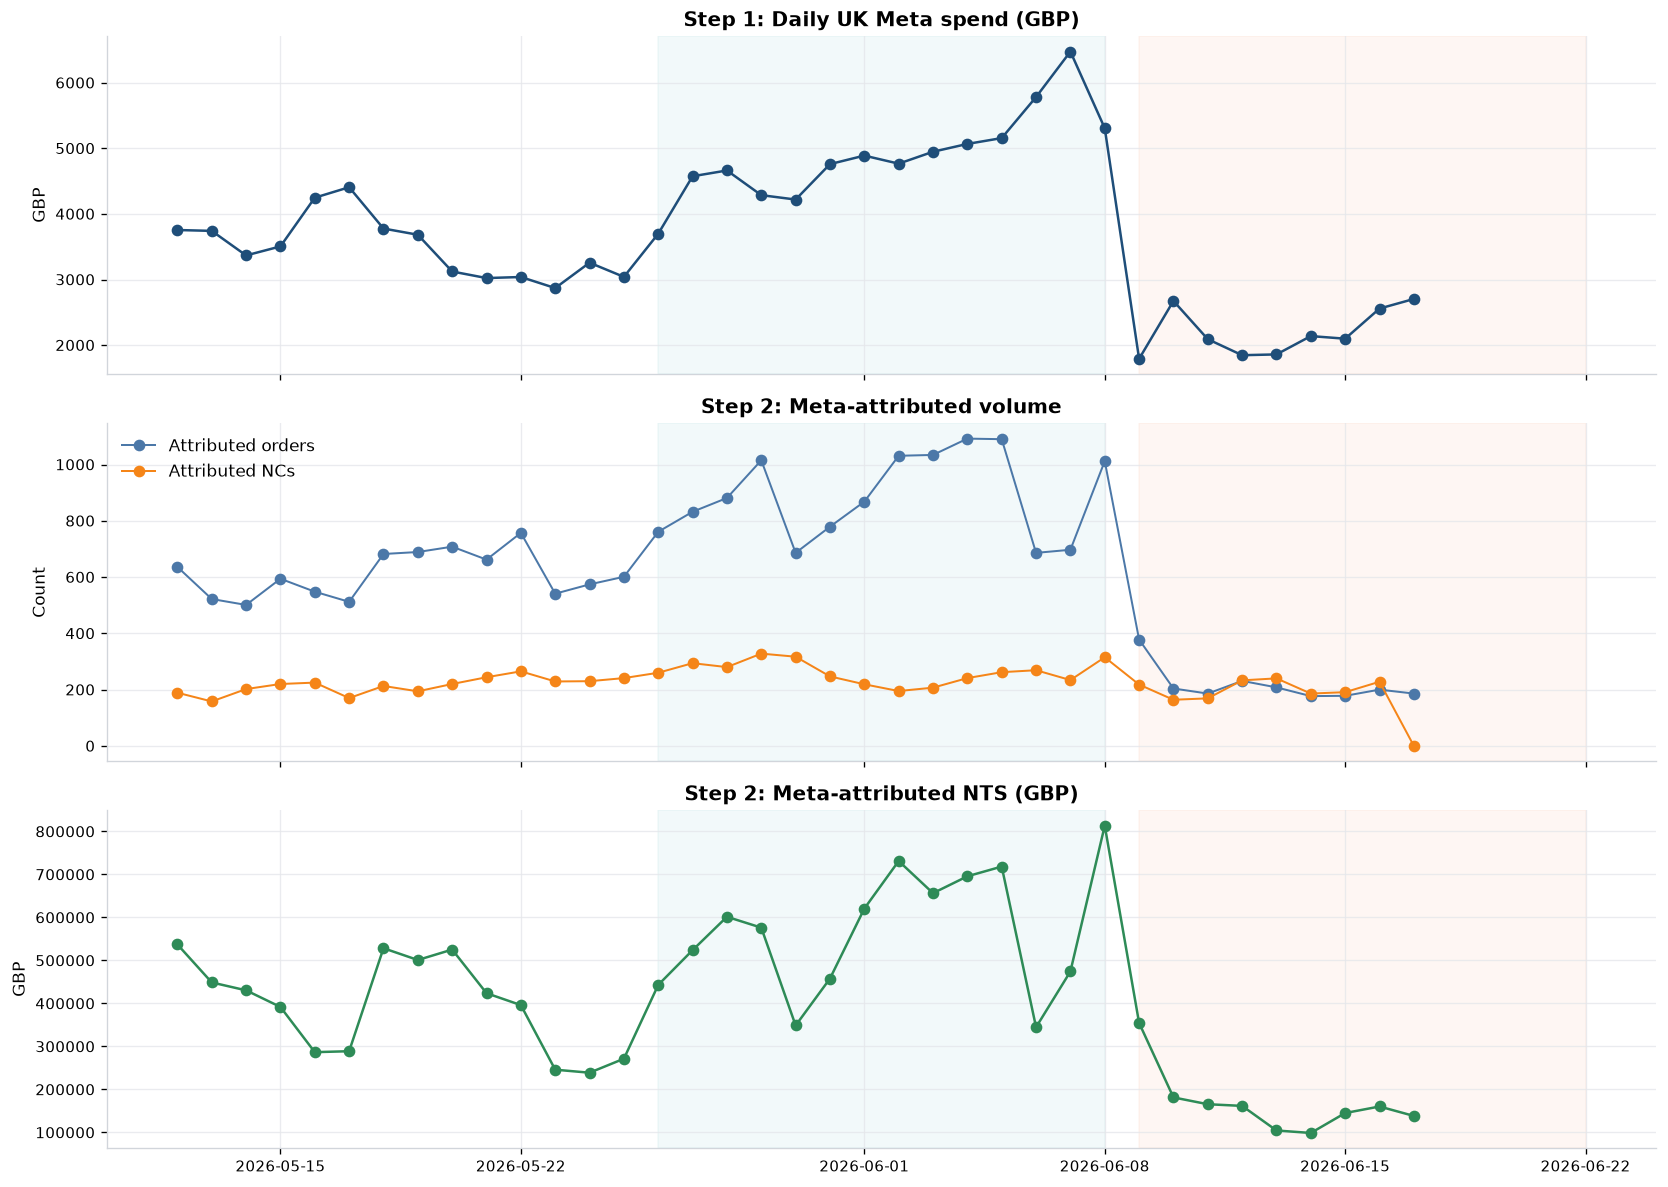

In [ ]:
# Step 1 + 2: treatment check (Meta spend changed?) and attributed sanity check.
q_meta_daily = """
SELECT
    DATE(activity_date) AS activity_date,
    SUM(marketing_spend_gbp)          AS meta_spend_gbp,
    SUM(platform_conversions)         AS meta_attr_orders,
    SUM(new_customer_count)           AS meta_attr_ncs,
    SUM(platform_conversions_trx_value_gbp) AS meta_attr_nts_gbp
FROM bi_dwh.marketing_yield
WHERE DATE(activity_date) BETWEEN DATE '2026-05-12' AND DATE '2026-07-06'
  AND region = 'United Kingdom'
  AND channel_1 = 'Paid Social'
  AND channel_2 = 'Facebook'
  AND original_attribution = FALSE
GROUP BY 1
ORDER BY 1
"""

df_meta = run_sql(q_meta_daily)
df_meta = add_phase(df_meta, "activity_date")

meta_phase_summary = phase_summary(
    df_meta,
    ["meta_spend_gbp", "meta_attr_orders", "meta_attr_ncs", "meta_attr_nts_gbp"],
)
print("Step 1/2 phase summary:")
meta_phase_summary

# Expected vs actual spend deltas by treatment phase.
pre_daily_spend = df_meta.loc[df_meta["phase"] == "pre", "meta_spend_gbp"].mean()
rows = []
for phase_name, exp_delta in [
    ("phase1_plus28k", 28000),
    ("phase2_minus28k", -28000),
]:
    d = df_meta[df_meta["phase"] == phase_name]
    days = len(d)
    actual_total = d["meta_spend_gbp"].sum()
    expected_no_treatment = pre_daily_spend * days
    actual_delta_vs_pre_level = actual_total - expected_no_treatment
    rows.append(
        {
            "phase": phase_name,
            "days": days,
            "expected_spend_change_gbp": exp_delta,
            "actual_spend_change_vs_pre_level_gbp": actual_delta_vs_pre_level,
            "gap_actual_minus_expected_gbp": actual_delta_vs_pre_level - exp_delta,
        }
    )
spend_validation = pd.DataFrame(rows)
print("\nTreatment validation (expected vs actual spend change):")
spend_validation

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_meta["activity_date"], df_meta["meta_spend_gbp"], marker="o", color=PLOT_COLORS["primary"], linewidth=1.5)
style_axis(axes[0], title="Step 1: Daily UK Meta spend (GBP)", ylabel="GBP")

axes[1].plot(df_meta["activity_date"], df_meta["meta_attr_orders"], marker="o", color=PLOT_COLORS["secondary"], linewidth=1.2, label="Attributed orders")
axes[1].plot(df_meta["activity_date"], df_meta["meta_attr_ncs"], marker="o", color=PLOT_COLORS["accent"], linewidth=1.2, label="Attributed NCs")
style_axis(axes[1], title="Step 2: Meta-attributed volume", ylabel="Count")
axes[1].legend()

axes[2].plot(df_meta["activity_date"], df_meta["meta_attr_nts_gbp"], marker="o", color=PLOT_COLORS["success"], linewidth=1.5)
style_axis(axes[2], title="Step 2: Meta-attributed NTS (GBP)", ylabel="GBP")

for ax in axes:
    add_phase_spans(ax, {
        "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
        "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
    })

plt.tight_layout()

## Step 3 + 4: Did Total UK Sales Move? And Was It Unique to UK?

**Step 3 — Total UK NTS:** We use `fm_products` (the source-of-truth order table) rather than `marketing_yield` here. This captures *all* UK demand — not just what's attributed to Meta — so it's immune to attribution model errors or cookie consent gaps.

**Step 4 — Control comparison:** We pull the same metric for France, Spain, and Italy, then compute a daily ratio of UK NTS vs the average of the three control markets. 

- If **UK moves up in Phase 1 but France/Spain/Italy don't** → strong signal the uplift is Meta-driven
- If **all four markets move together** → it's a macro/seasonal effect we can't attribute to Meta

**Key output:** `did_summary` — the difference-in-differences estimate:
- `did_total_gbp_per_day` = UK daily delta minus control daily delta
- This is our cleanest causal estimate of the Meta spend effect on total demand (equivalent to Tom's pre vs during comparison for Italy)

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Step 3: UK total sales phase summary

Step 4: UK vs control summary by phase


,phase,total_nts_gbp_sum,total_nts_gbp_mean,total_nts_gbp_median,control_nts_mean_sum,control_nts_mean_mean,control_nts_mean_median,uk_control_nts_ratio_sum,uk_control_nts_ratio_mean,uk_control_nts_ratio_median,days
0,phase1_plus28k,1.937859e+08,1.384185e+07,1.468502e+07,1.225638e+07,875455.938981,918190.514339,221.547830,15.824845,15.773324,14
1,phase2_minus28k,1.278103e+08,1.420115e+07,1.527436e+07,8.147040e+06,905226.647216,935236.598498,140.991071,15.665675,15.816934,9
2,pre,1.836200e+08,1.311571e+07,1.418953e+07,1.058817e+07,756298.058103,809273.995929,243.433453,17.388104,17.618691,14


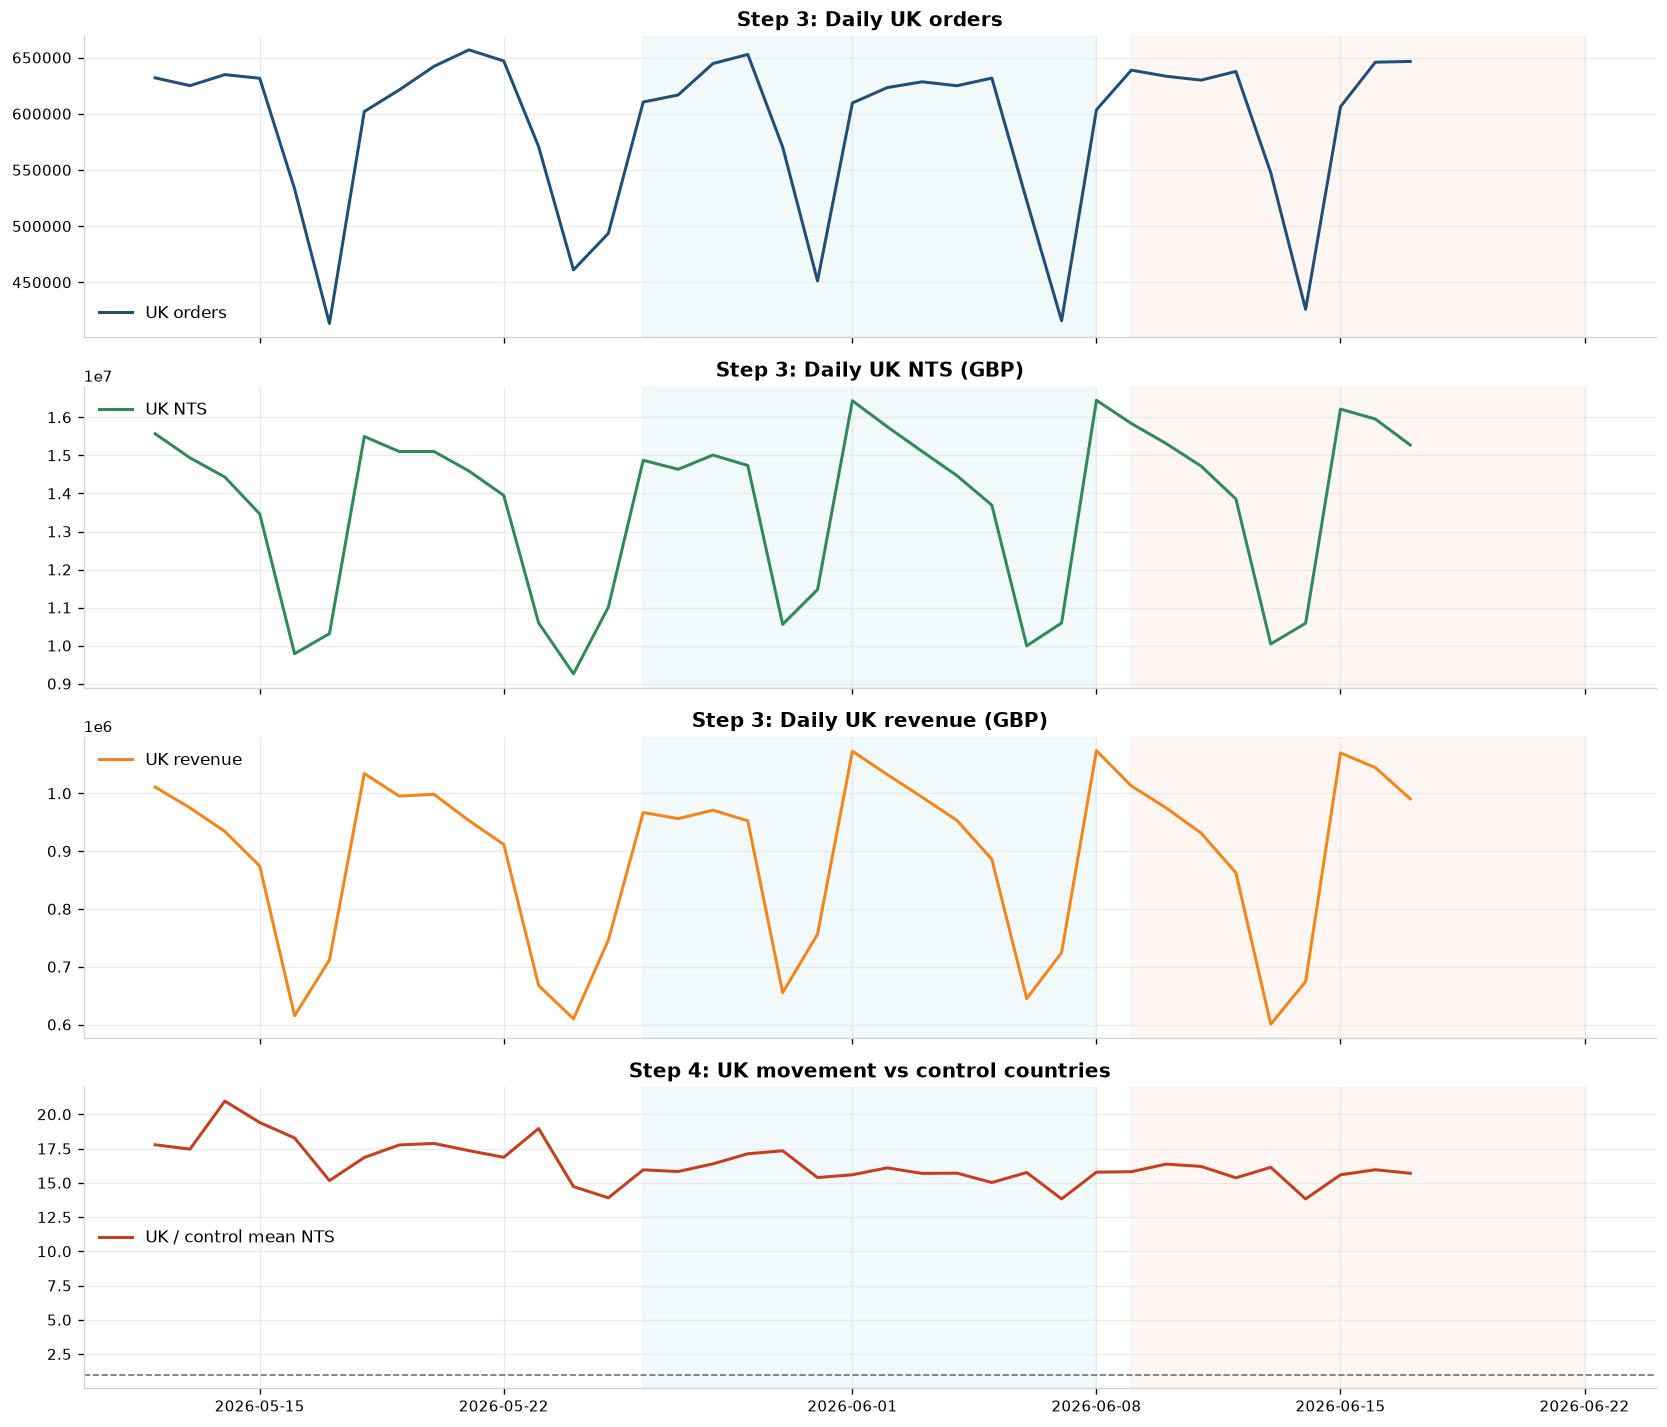

In [ ]:
# Step 3 + 4: total UK sales (fm_products) and control comparison.
q_sales = """
SELECT
    DATE(order_date) AS activity_date,
    order_region_name AS region,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(m_net_sales_amount_gbp)  AS total_nts_gbp,
    SUM(m_revenue_total_gbp)     AS total_revenue_gbp
FROM bi_dwh.fm_products
WHERE DATE(order_date) BETWEEN DATE '2026-05-12' AND DATE '2026-07-06'
  AND order_region_name IN ('United Kingdom', 'France', 'Spain', 'Italy')
  AND order_confirmed_date IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
"""

df_sales = run_sql(q_sales)
df_sales = add_phase(df_sales, "activity_date")

uk_sales     = df_sales[df_sales["region"] == "United Kingdom"].copy()
controls_sales = df_sales[df_sales["region"].isin(["France", "Spain", "Italy"])].copy()

print("Step 3: UK total sales phase summary")
phase_summary(uk_sales, ["total_orders", "total_nts_gbp", "total_revenue_gbp"])

controls_daily = (
    controls_sales.groupby("activity_date", as_index=False)
    .agg(
        control_orders_mean=("total_orders", "mean"),
        control_nts_mean=("total_nts_gbp", "mean"),
        control_revenue_mean=("total_revenue_gbp", "mean"),
    )
)

uk_vs_ctrl = uk_sales.merge(controls_daily, on="activity_date", how="left")
uk_vs_ctrl = add_phase(uk_vs_ctrl, "activity_date")
uk_vs_ctrl["uk_control_nts_ratio"] = uk_vs_ctrl["total_nts_gbp"] / uk_vs_ctrl["control_nts_mean"]

phase_spans = {
    "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
    "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(uk_sales["activity_date"], uk_sales["total_orders"], label="UK orders", color=PLOT_COLORS["primary"])
style_axis(axes[0], title="Step 3: Daily UK orders")
axes[0].legend()

axes[1].plot(uk_sales["activity_date"], uk_sales["total_nts_gbp"], label="UK NTS", color=PLOT_COLORS["success"])
style_axis(axes[1], title="Step 3: Daily UK NTS (GBP)")
axes[1].legend()

axes[2].plot(uk_sales["activity_date"], uk_sales["total_revenue_gbp"], label="UK revenue", color=PLOT_COLORS["accent"])
style_axis(axes[2], title="Step 3: Daily UK revenue (GBP)")
axes[2].legend()

axes[3].plot(uk_vs_ctrl["activity_date"], uk_vs_ctrl["uk_control_nts_ratio"], label="UK / control mean NTS", color=PLOT_COLORS["danger"])
axes[3].axhline(1.0, linestyle="--", linewidth=1, color=PLOT_COLORS["neutral"])
style_axis(axes[3], title="Step 4: UK movement vs control countries")
axes[3].legend()

for ax in axes:
    add_phase_spans(ax, phase_spans)

plt.tight_layout()

print("\nStep 4: UK vs control summary by phase")
phase_summary(uk_vs_ctrl, ["total_nts_gbp", "control_nts_mean", "uk_control_nts_ratio"])

## Step 5: Isolating the Organic Baseline (Difference-in-Differences)

Here we construct a "baseline demand" series by subtracting Meta-attributed NTS from total UK NTS:

```
uk_baseline_nts_gbp = total_nts_gbp − meta_attr_nts_gbp
```

**Why this matters:**
- If **total NTS rises** during Phase 1 but **baseline stays flat** → the uplift is just attributed Meta sales moving, not genuine incremental demand being created
- If **baseline also rises** → Meta spend is pulling in genuinely new demand that wasn't going to book anyway (halo effect or direct incrementality beyond last-click)

**The DiD table** then compares both the total and baseline deltas against the control countries, giving us high and low bounds on the true incremental effect:

| Column | Meaning |
|---|---|
| `uk_total_delta_vs_pre_gbp_per_day` | How much UK total NTS changed vs pre |
| `uk_baseline_delta_vs_pre_gbp_per_day` | Same but stripping out Meta-attributed |
| `control_delta_vs_pre_gbp_per_day` | How much control markets changed (macro signal) |
| `did_total_gbp_per_day` | UK delta minus control delta = our causal estimate |

Step 5: Difference-in-differences summary (daily deltas)


,phase,uk_total_delta_vs_pre_gbp_per_day,uk_baseline_delta_vs_pre_gbp_per_day,control_delta_vs_pre_gbp_per_day,did_total_gbp_per_day,did_baseline_gbp_per_day
0,phase1_plus28k,7.261360e+05,5.481959e+05,119157.880878,606978.118760,4.290380e+05
1,phase2_minus28k,1.085434e+06,1.311499e+06,148928.589114,936505.852821,1.162570e+06


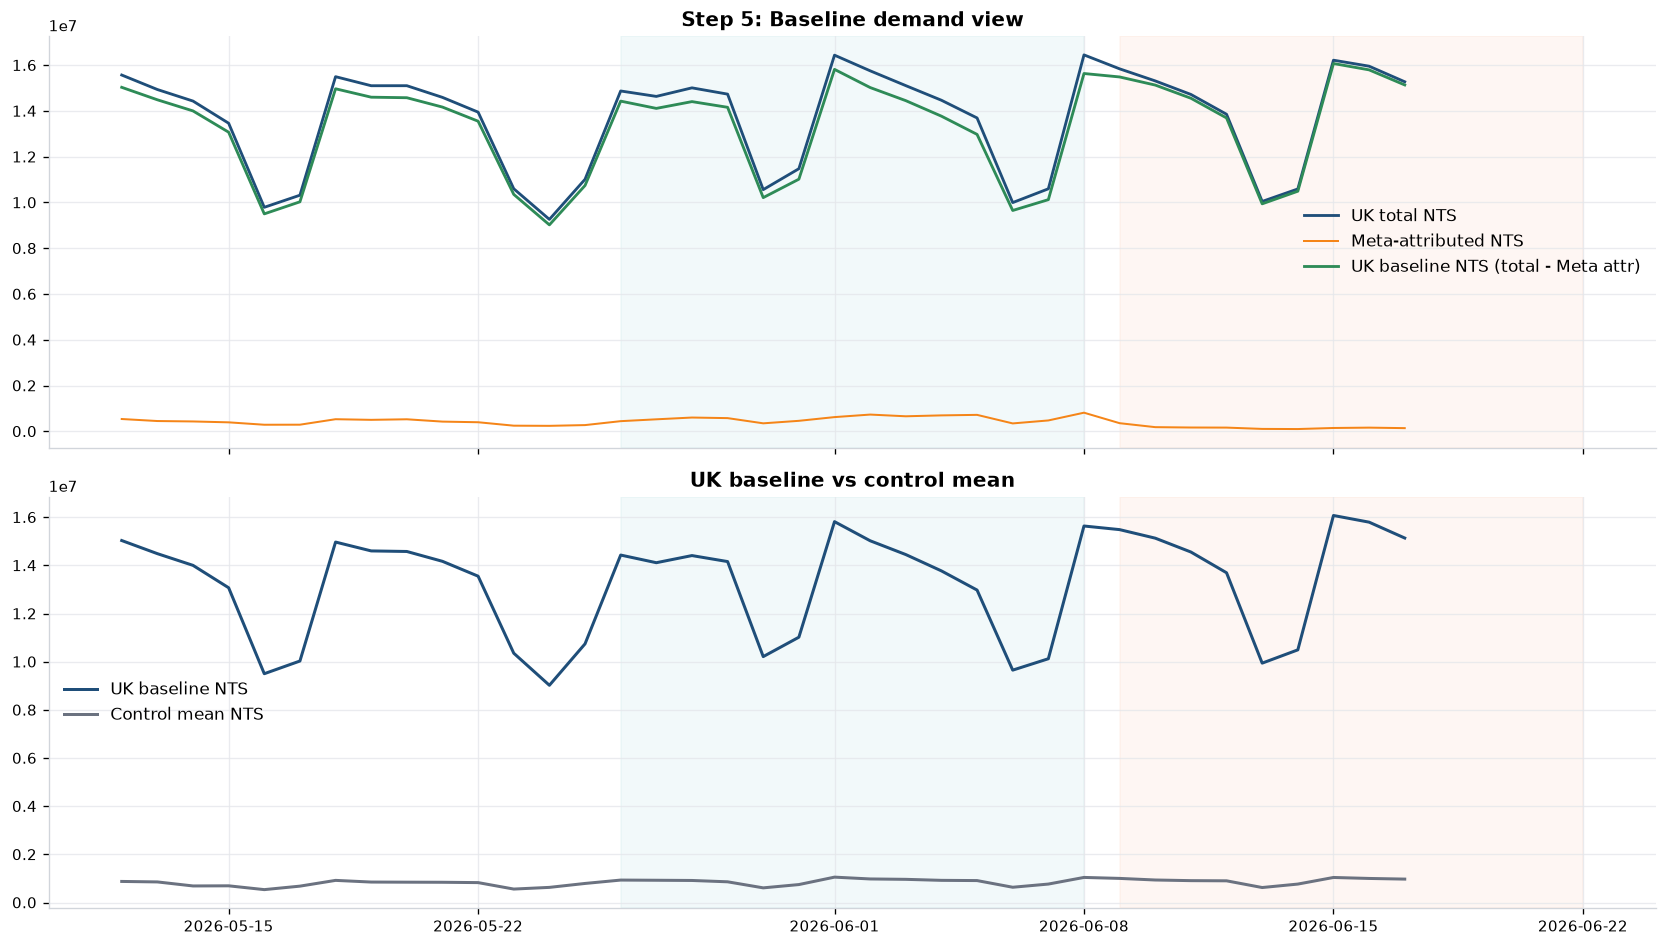

In [ ]:
# Step 5: baseline view + simple difference-in-differences estimates.
meta_nts_daily = df_meta[["activity_date", "meta_attr_nts_gbp"]].copy()
uk_eval = uk_vs_ctrl.merge(meta_nts_daily, on="activity_date", how="left")
uk_eval["meta_attr_nts_gbp"] = uk_eval["meta_attr_nts_gbp"].fillna(0)
uk_eval["uk_baseline_nts_gbp"] = uk_eval["total_nts_gbp"] - uk_eval["meta_attr_nts_gbp"]
uk_eval = add_phase(uk_eval, "activity_date")

phase_spans = {
    "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
    "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(uk_eval["activity_date"], uk_eval["total_nts_gbp"], label="UK total NTS", color=PLOT_COLORS["primary"], linewidth=1.7)
axes[0].plot(uk_eval["activity_date"], uk_eval["meta_attr_nts_gbp"], label="Meta-attributed NTS", color=PLOT_COLORS["accent"], linewidth=1.2)
axes[0].plot(uk_eval["activity_date"], uk_eval["uk_baseline_nts_gbp"], label="UK baseline NTS (total - Meta attr)", color=PLOT_COLORS["success"], linewidth=1.7)
style_axis(axes[0], title="Step 5: Baseline demand view")
axes[0].legend()

axes[1].plot(uk_eval["activity_date"], uk_eval["uk_baseline_nts_gbp"], label="UK baseline NTS", color=PLOT_COLORS["primary"])
axes[1].plot(uk_eval["activity_date"], uk_eval["control_nts_mean"], label="Control mean NTS", color=PLOT_COLORS["neutral"])
style_axis(axes[1], title="UK baseline vs control mean")
axes[1].legend()

for ax in axes:
    add_phase_spans(ax, phase_spans)

plt.tight_layout()

pre_uk_total    = uk_eval.loc[uk_eval["phase"] == "pre", "total_nts_gbp"].mean()
pre_uk_baseline = uk_eval.loc[uk_eval["phase"] == "pre", "uk_baseline_nts_gbp"].mean()
pre_ctrl        = uk_eval.loc[uk_eval["phase"] == "pre", "control_nts_mean"].mean()

did_rows = []
for phase in ["phase1_plus28k", "phase2_minus28k"]:
    uk_total_delta    = uk_eval.loc[uk_eval["phase"] == phase, "total_nts_gbp"].mean() - pre_uk_total
    uk_baseline_delta = uk_eval.loc[uk_eval["phase"] == phase, "uk_baseline_nts_gbp"].mean() - pre_uk_baseline
    ctrl_delta        = uk_eval.loc[uk_eval["phase"] == phase, "control_nts_mean"].mean() - pre_ctrl
    did_rows.append(
        {
            "phase": phase,
            "uk_total_delta_vs_pre_gbp_per_day": uk_total_delta,
            "uk_baseline_delta_vs_pre_gbp_per_day": uk_baseline_delta,
            "control_delta_vs_pre_gbp_per_day": ctrl_delta,
            "did_total_gbp_per_day": uk_total_delta - ctrl_delta,
            "did_baseline_gbp_per_day": uk_baseline_delta - ctrl_delta,
        }
    )

did_summary = pd.DataFrame(did_rows)
print("Step 5: Difference-in-differences summary (daily deltas)")
did_summary

## Step 6: Channel Substitution Check

When Meta spend doubles, do organic/SEO/Direct channels pick up traffic? When Meta is cut, do other channels compensate? This is important because substitution effects would mean the true Meta increment is *smaller* than the spend change implies.

We pull all channel NTS from `marketing_yield` and **index each channel to its pre-period average (= 100)**. So if a channel reads 110 during Phase 1, it gained 10% — possibly absorbing demand that Meta drove to site but that converted via a different last-click channel.

**The `corr_df` correlation table is the key diagnostic:**
- **Negative correlation with Paid Social** → channel is acting as a substitute (gaining when Meta loses, or losing when Meta gains) — suggests cannibalisation
- **Positive correlation** → channels move together — no substitution, or they share a common macro driver

Tom found that for Italy, SEO picked up ~15% of the NC decline and ~8% of the NTS decline when PPC was cut. We'd expect something similar here if the UK dynamics are comparable.

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Step 6: substitution diagnostic (correlation with Paid Social attributed NTS)


/opt/miniconda3/envs/ppcenv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ppcenv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,channel,corr_with_meta_attr_nts
0,Paid Search,0.771014
1,SEO,NaN


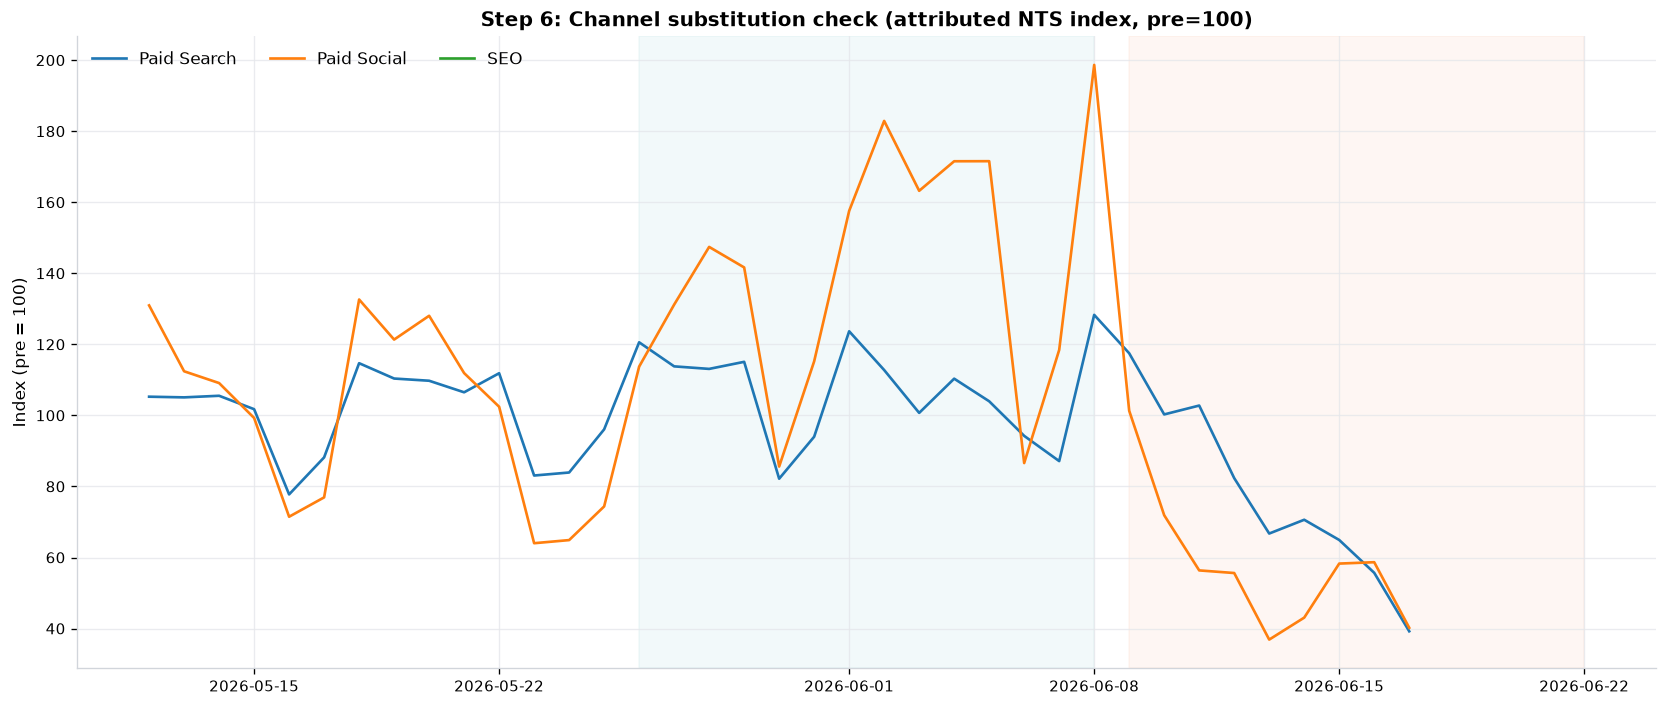

In [ ]:
# Step 6: substitution effects across channels.
q_sub = """
SELECT
    DATE(activity_date) AS activity_date,
    channel_1,
    SUM(marketing_spend_gbp)               AS spend_gbp,
    SUM(platform_conversions_trx_value_gbp) AS attr_nts_gbp,
    SUM(new_customer_count)                AS attr_ncs
FROM bi_dwh.marketing_yield
WHERE DATE(activity_date) BETWEEN DATE '2026-05-12' AND DATE '2026-07-06'
  AND region = 'United Kingdom'
  AND original_attribution = FALSE
GROUP BY 1, 2
ORDER BY 1, 2
"""

df_sub = run_sql(q_sub)
df_sub = add_phase(df_sub, "activity_date")

substitution_channels = ["SEO", "Direct", "Paid Search", "Organic", "Paid Social"]
df_sub_f = df_sub[df_sub["channel_1"].isin(substitution_channels)].copy()
sub_pivot = (
    df_sub_f.pivot_table(index="activity_date", columns="channel_1", values="attr_nts_gbp", aggfunc="sum")
    .sort_index()
    .fillna(0)
)

# Index each channel to pre-phase average = 100 for comparability.
pre_mask = (sub_pivot.index >= pd.to_datetime("2026-05-12")) & (sub_pivot.index <= pd.to_datetime("2026-05-25"))
pre_avg = sub_pivot.loc[pre_mask].mean().replace(0, np.nan)
sub_indexed = (sub_pivot / pre_avg) * 100

phase_spans = {
    "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
    "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
}

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(sub_indexed.columns):
    color = plt.get_cmap("tab10")(i % 10)
    ax.plot(sub_indexed.index, sub_indexed[col], linewidth=1.6, label=col, color=color)

style_axis(ax, title="Step 6: Channel substitution check (attributed NTS index, pre=100)", ylabel="Index (pre = 100)")
add_phase_spans(ax, phase_spans)
ax.legend(ncol=3)
plt.tight_layout()

# Correlation diagnostic: negative corr with Paid Social may indicate substitution.
meta_series = sub_pivot.get("Paid Social")
corr_rows = []
if meta_series is not None:
    for c in sub_pivot.columns:
        if c == "Paid Social":
            continue
        corr = meta_series.corr(sub_pivot[c])
        corr_rows.append({"channel": c, "corr_with_meta_attr_nts": corr})

corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_meta_attr_nts") if corr_rows else pd.DataFrame()
print("Step 6: substitution diagnostic (correlation with Paid Social attributed NTS)")
corr_df

## Step 6b: Web Visits and NC Breakdown by Channel

Two supporting diagnostics that sit alongside the substitution check:

**Web visits (mweb + dtweb):** Did overall site traffic move with Meta spend? Meta drives top-of-funnel awareness — if visits don't rise during Phase 1, it suggests Meta isn't pulling in net new users (more likely re-targeting existing high-intent users). Tom found UK visits dropped ~18% during the Italy spend cut — we'd expect a similar signal here in reverse during the upweight.

**NC breakdown by channel bucket:** We classify all channels into Meta / PPC / SEO / Direct and track daily new customers for each. **Indexed to the pre-period (= 100)**, this shows:
- Whether Meta NCs spiked as expected in Phase 1 (sanity check)
- Whether SEO/Direct NCs held flat (good — no cannibalisation) or dipped (bad — or maybe just a macro headwind)
- Whether PPC was unaffected (it shouldn't be, unless budgets were reallocated)

Together, visits + NC context tells you *where in the funnel* the Meta effect is showing up — top-of-funnel demand creation vs bottom-of-funnel attribution shift.

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)
/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Step 6b: visits and NC context summary by phase


,phase,web_visits_sum,web_visits_mean,web_visits_median,total_attr_new_customers_sum,total_attr_new_customers_mean,total_attr_new_customers_median,Meta_sum,Meta_mean,Meta_median,PPC_sum,PPC_mean,PPC_median,SEO_sum,SEO_mean,SEO_median,days
0,phase1_plus28k,5339625,381401.785714,390749.5,143869.000004,10276.357143,10107.500000,3668.0,262.000000,261.0,21720.738368,1551.481312,1548.492094,33992.386160,2428.027583,2503.037826,14
1,phase2_minus28k,2816530,352066.250000,371258.0,79739.000012,9967.375002,9861.500001,1629.0,203.625000,204.5,10863.419731,1357.927466,1348.027628,19043.602405,2380.450301,2430.978569,8
2,pre,5155119,368222.785714,378655.5,137375.000014,9812.500001,9692.500002,3000.0,214.285714,220.0,20470.727698,1462.194836,1432.020959,32020.554285,2287.182449,2347.082927,14


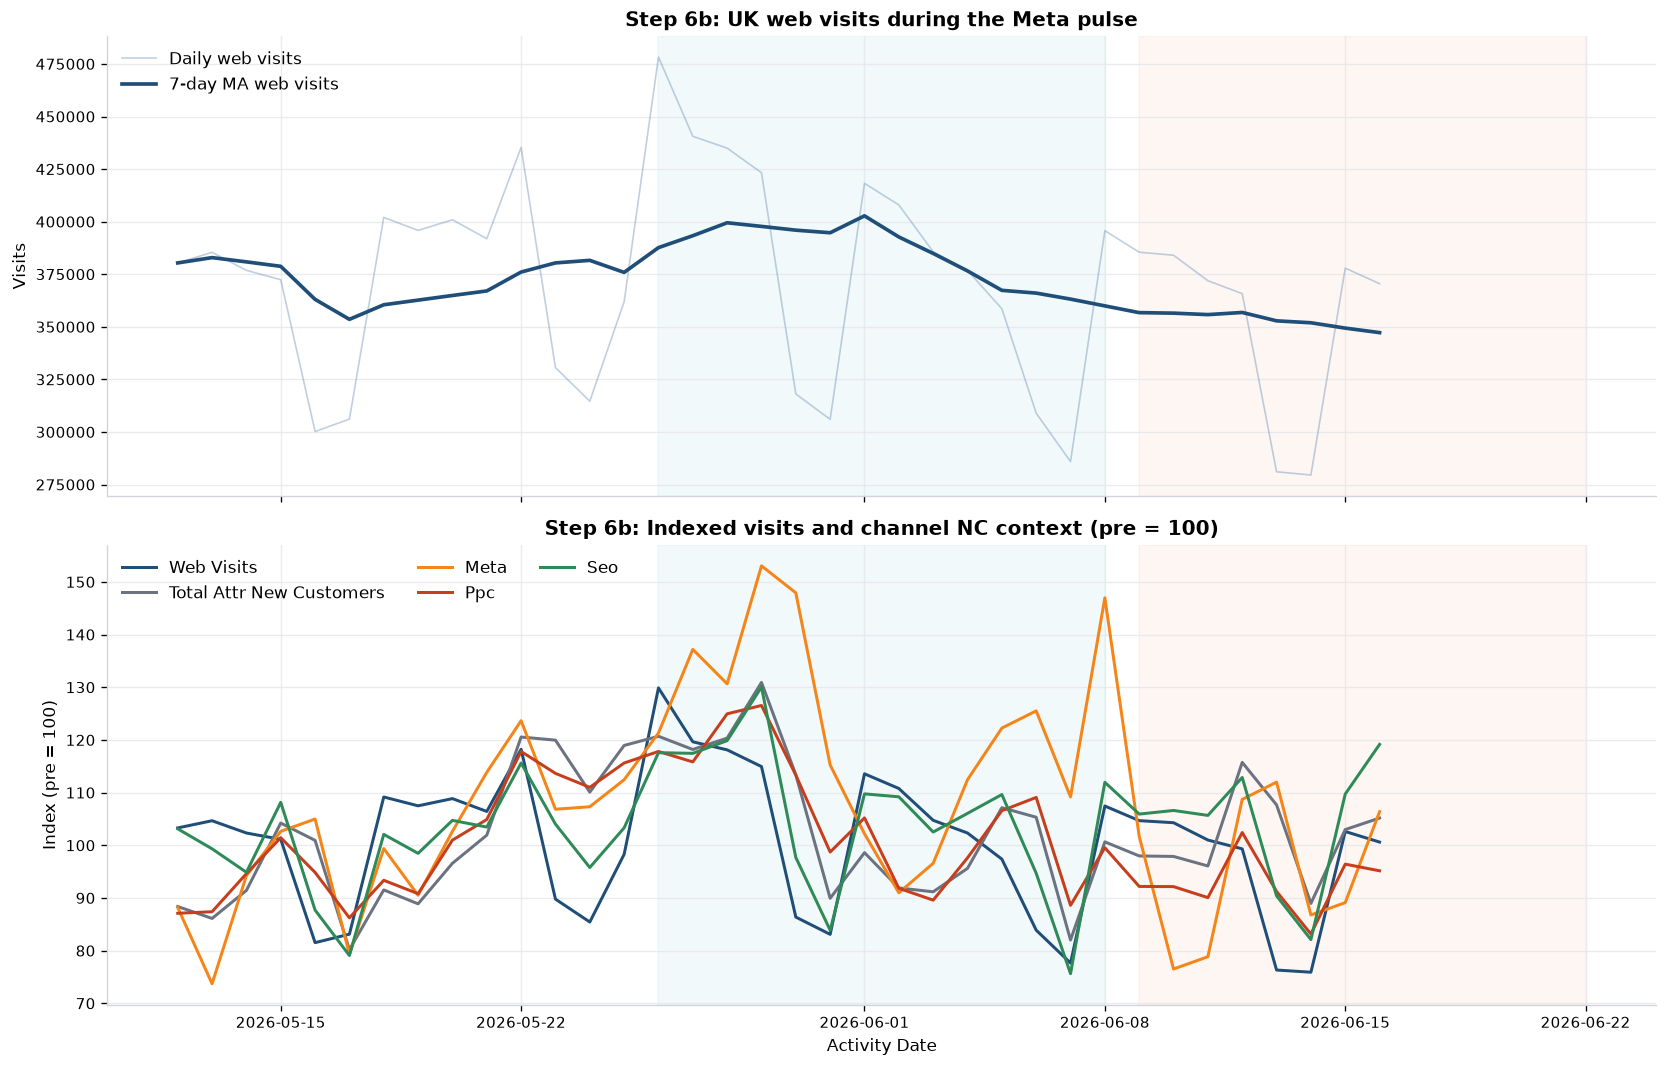

In [ ]:
# Step 6b: UK visits and broader channel NC context.
q_visits = """
SELECT
    DATE(year_month_day) AS activity_date,
    COUNT(DISTINCT visit_id) AS web_visits
FROM bi_dwh.user_visits
WHERE platform IN ('mweb', 'dtweb')
  AND UPPER(region_name) = UPPER('United Kingdom')
  AND DATE(year_month_day) BETWEEN DATE '2026-05-12' AND DATE '2026-07-06'
GROUP BY 1
ORDER BY 1
"""

q_channel_nc = """
SELECT
    DATE(activity_date) AS activity_date,
    channel_0,
    channel_1,
    channel_2,
    SUM(new_customer_count) AS new_customers
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
  AND region = 'United Kingdom'
  AND DATE(activity_date) BETWEEN DATE '2026-05-12' AND DATE '2026-07-06'
GROUP BY 1, 2, 3, 4
ORDER BY 1, 2, 3, 4
"""

df_visits = run_sql(q_visits)
df_visits = add_phase(df_visits, "activity_date")

df_channel_nc = run_sql(q_channel_nc)
df_channel_nc["activity_date"] = pd.to_datetime(df_channel_nc["activity_date"])


def classify_channel_bucket(row: pd.Series) -> str | None:
    if row["channel_0"] == "Web - Paid Social"  and row["channel_2"] == "Facebook":
        return "Meta"
    if row["channel_0"] == "Web - Paid Search"  and row["channel_2"] == "Google":
        return "PPC"
    if row["channel_0"] == "Organic Search"     and row["channel_1"] == "SEO":
        return "SEO"
    if row["channel_0"] == "Direct":
        return "Direct"
    if row["channel_0"] == "Organic Search":
        return "Organic Search"
    return None


df_channel_nc["bucket"] = df_channel_nc.apply(classify_channel_bucket, axis=1)
df_bucket_nc = df_channel_nc[df_channel_nc["bucket"].notna()].copy()

bucket_nc_daily = (
    df_bucket_nc.groupby(["activity_date", "bucket"], as_index=False)["new_customers"]
    .sum()
    .pivot(index="activity_date", columns="bucket", values="new_customers")
    .fillna(0)
    .reset_index()
)

total_attr_nc_daily = (
    df_channel_nc.groupby("activity_date", as_index=False)["new_customers"]
    .sum()
    .rename(columns={"new_customers": "total_attr_new_customers"})
)

uk_support = df_visits.merge(total_attr_nc_daily, on="activity_date", how="left")
uk_support = uk_support.merge(bucket_nc_daily, on="activity_date", how="left")
uk_support = uk_support.fillna(0)
uk_support = add_phase(uk_support, "activity_date")
support_index_cols = [c for c in ["web_visits", "total_attr_new_customers", "Meta", "PPC", "SEO"] if c in uk_support.columns]
uk_support = add_rolling_columns(
    uk_support.sort_values("activity_date"),
    support_index_cols,
    window=7,
    suffix="ma",
)

phase_spans = {
    "phase1_start": "2026-05-26", "phase1_end": "2026-06-08",
    "phase2_start": "2026-06-09", "phase2_end": "2026-06-22",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(uk_support["activity_date"], uk_support["web_visits"], color=PLOT_COLORS["secondary"], alpha=0.35, linewidth=1.0, label="Daily web visits")
axes[0].plot(uk_support["activity_date"], uk_support["web_visits_ma7"], color=PLOT_COLORS["primary"], linewidth=2.2, label="7-day MA web visits")
style_axis(axes[0], title="Step 6b: UK web visits during the Meta pulse", ylabel="Visits")
axes[0].legend()

support_index = uk_support[["activity_date", *support_index_cols]].copy()
pre_mask = support_index["activity_date"].between(pd.to_datetime("2026-05-12"), pd.to_datetime("2026-05-25"))
pre_means = support_index.loc[pre_mask, support_index_cols].mean().replace(0, np.nan)
for col in support_index_cols:
    support_index[col] = (support_index[col] / pre_means[col]) * 100

color_map = {
    "web_visits": PLOT_COLORS["primary"],
    "total_attr_new_customers": PLOT_COLORS["neutral"],
    "Meta": PLOT_COLORS["accent"],
    "PPC": PLOT_COLORS["danger"],
    "SEO": PLOT_COLORS["success"],
}
for col in support_index_cols:
    axes[1].plot(support_index["activity_date"], support_index[col], linewidth=1.8, label=col.replace("_", " ").title(), color=color_map.get(col, plt.get_cmap("tab10")(0)))
style_axis(axes[1], title="Step 6b: Indexed visits and channel NC context (pre = 100)", ylabel="Index (pre = 100)", xlabel="Activity Date")
axes[1].legend(ncol=3)

for ax in axes:
    add_phase_spans(ax, phase_spans)

plt.tight_layout()

print("Step 6b: visits and NC context summary by phase")
phase_summary(uk_support, support_index_cols)

## Step 7: Expected vs Observed Impact — The Scorecard

Final scorecard. For each test phase we compute the total observed NTS impact (actual minus pre-period counterfactual) and compare it to the pre-test expectation:

| Phase | Expected NTS impact | Basis |
|---|---|---|
| Phase 1 (upweight) | +£420k total NTS | Marginals dashboard iROAS × £28k extra spend |
| Phase 2 (downweight) | -£840k total NTS | Symmetric assumption: 2x magnitude for full cut vs partial upweight |

**Three observed lines to compare against those expectations:**
- `observed_total_nts_impact_gbp` — raw UK NTS vs pre-period counterfactual
- `observed_baseline_nts_impact_gbp` — same but stripping out attributed Meta NTS (avoids double-counting)
- `observed_meta_attr_nts_impact_gbp` — just what `marketing_yield` credits to Meta last-click

**How to interpret the gaps:**
- `gap_baseline_minus_expected` ≈ 0 → incrementality estimate is validated ✅
- Gap is large positive → test underdelivered (spend didn't cause as much demand as predicted)
- Only attributed NTS moves but baseline stays flat → attribution shift, not genuine demand creation — needs further investigation
- Large confound in the period (Euro 2026, bank holiday) → adjust interpretation accordingly

This table is the equivalent of Tom's "predicted vs estimated NC/NTS impact" table in the Italy analysis.

Expected vs observed NTS impact

Interpretation checklist:
1) Treatment happened? -> check spend_validation
2) Attributed moved? -> check df_meta plots and summaries
3) Baseline moved in same direction as spend? -> check uk_baseline_nts_gbp
4) UK moved differently vs controls? -> check did_summary
5) Magnitude close to expected (420k / -840k)? -> check impact_df


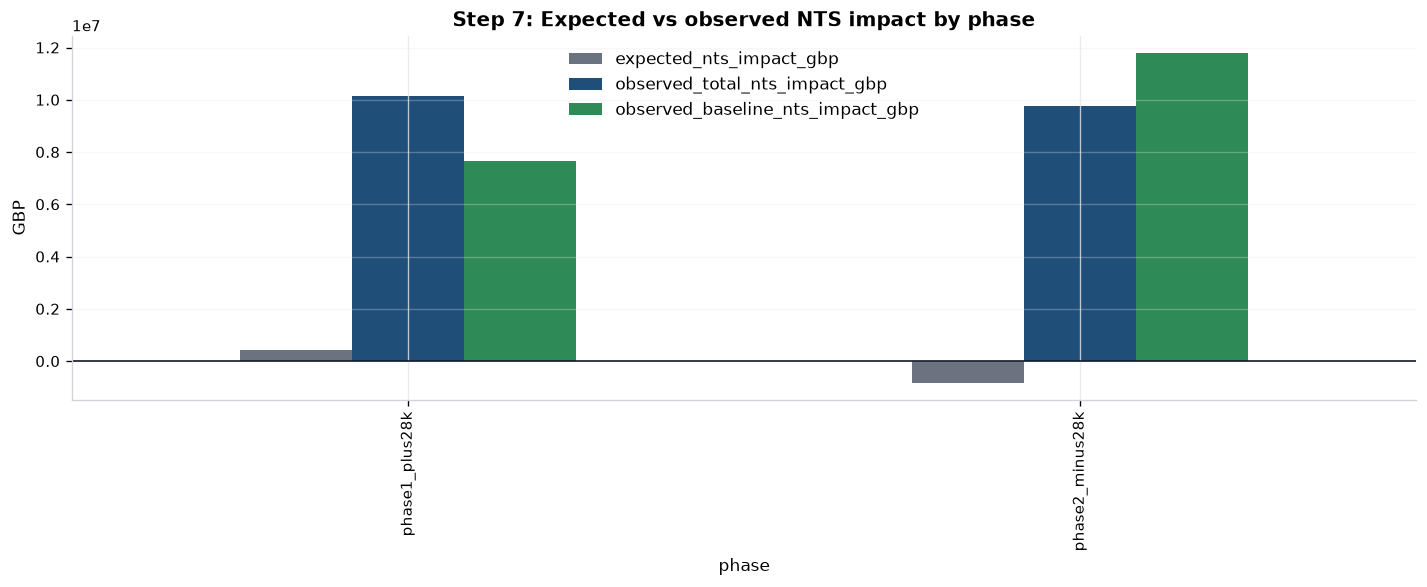

In [ ]:
# Step 7: expected vs observed impact.
expected_nts_by_phase = {
    "phase1_plus28k":  420000,
    "phase2_minus28k": -840000,
}

pre_total_daily    = uk_eval.loc[uk_eval["phase"] == "pre", "total_nts_gbp"].mean()
pre_baseline_daily = uk_eval.loc[uk_eval["phase"] == "pre", "uk_baseline_nts_gbp"].mean()
pre_meta_daily     = uk_eval.loc[uk_eval["phase"] == "pre", "meta_attr_nts_gbp"].mean()

impact_rows = []
for phase, expected_nts in expected_nts_by_phase.items():
    d = uk_eval[uk_eval["phase"] == phase]
    days = len(d)
    observed_total_impact    = d["total_nts_gbp"].sum()      - (pre_total_daily    * days)
    observed_baseline_impact = d["uk_baseline_nts_gbp"].sum() - (pre_baseline_daily * days)
    observed_meta_attr_impact = d["meta_attr_nts_gbp"].sum()  - (pre_meta_daily      * days)
    impact_rows.append(
        {
            "phase": phase,
            "days": days,
            "expected_nts_impact_gbp": expected_nts,
            "observed_total_nts_impact_gbp": observed_total_impact,
            "observed_baseline_nts_impact_gbp": observed_baseline_impact,
            "observed_meta_attr_nts_impact_gbp": observed_meta_attr_impact,
            "gap_total_minus_expected_gbp": observed_total_impact - expected_nts,
            "gap_baseline_minus_expected_gbp": observed_baseline_impact - expected_nts,
        }
    )

impact_df = pd.DataFrame(impact_rows)
print("Expected vs observed NTS impact")
impact_df

impact_plot = impact_df.set_index("phase")[[
    "expected_nts_impact_gbp",
    "observed_total_nts_impact_gbp",
    "observed_baseline_nts_impact_gbp",
]]

fig, ax = plt.subplots(figsize=(12, 5))
impact_plot.plot(kind="bar", ax=ax, color=[PLOT_COLORS["neutral"], PLOT_COLORS["primary"], PLOT_COLORS["success"]])
style_axis(ax, title="Step 7: Expected vs observed NTS impact by phase", ylabel="GBP")
ax.axhline(0, linewidth=1, color="#111827")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

print("\nInterpretation checklist:")
print("1) Treatment happened? -> check spend_validation")
print("2) Attributed moved?   -> check df_meta plots and summaries")
print("3) Baseline moved in same direction as spend? -> check uk_baseline_nts_gbp")
print("4) UK moved differently vs controls? -> check did_summary")
print("5) Magnitude close to expected (420k / -840k)? -> check impact_df")

## Tom sql_query_box queries to use for UK Meta analysis

Below are hardcoded SQL templates adapted from Tom's `ad_hoc/tom/sql_query_box` patterns and aligned to this notebook.

Source references used:
- `20260518_meta_spend_split.sql` (Meta spend/channel taxonomy checks)
- `20251125_marketing_yields_check.sql` (campaign->channel grouping logic)
- `20250917_look_at_sizing_for_nts_over_time.sql` (pre/post baseline multiplier framing)
- `20250627_nts_per_country_per_week.sql` (weekly regional `fm_products` controls)
- `20250603_visits_distribution.sql` and `20251017_views_visits.sql` (visits context)
- `20251015_customer_acq_channel.sql` (marketing orders acquisition mapping logic)

These are intentionally plain SQL strings (no JSON/kson config abstraction).

In [60]:
# Tom query pack: hardcoded SQL templates adapted for this UK Meta pulse analysis.

analysis_start = str(globals().get('TEST_START', '2026-04-15'))
analysis_end = str(globals().get('TEST_END', '2026-07-15'))

q_tom_meta_yield = f"""
WITH marketing_yields_agg AS (
    SELECT
        DATE(activity_date) AS activity_date,
        region,
        campaign,
        channel_0,
        channel_1,
        channel_2,
        SUM(marketing_spend_gbp) AS spend_gbp,
        SUM(total_gross_sales_gbp) AS gross_sales_gbp,
        SUM(new_customer_count) AS new_customers,
        SUM(platform_conversions_nc) AS platform_conversions_nc
    FROM bi_dwh.marketing_yield
    WHERE original_attribution = FALSE
      AND DATE(activity_date) BETWEEN DATE('{analysis_start}') AND DATE('{analysis_end}')
      AND region = 'United Kingdom'
    GROUP BY 1,2,3,4,5,6
)
SELECT *
FROM marketing_yields_agg
WHERE (
        LOWER(COALESCE(channel_2, '')) LIKE '%meta%'
     OR LOWER(COALESCE(channel_2, '')) LIKE '%facebook%'
     OR LOWER(COALESCE(campaign, '')) LIKE '%meta%'
     OR LOWER(COALESCE(campaign, '')) LIKE '%facebook%'
)
ORDER BY activity_date;
"""

q_tom_channel_grouping_check = f"""
SELECT
    DATE(activity_date) AS activity_date,
    CASE
        WHEN campaign IS NULL THEN 'other'
        WHEN campaign LIKE '%ppc_gs%' AND campaign NOT LIKE '%brand%' THEN 'PPC'
        WHEN campaign LIKE '%_daps_%' THEN 'Web - Social'
        WHEN campaign LIKE '%app_uac%' THEN 'App - Low'
        WHEN campaign LIKE '%apple_search_ads%' THEN 'App - Mid'
        WHEN campaign LIKE '%facebook%' OR campaign LIKE '%meta%' THEN 'Meta / Paid Social'
        ELSE 'other'
    END AS channel_grouping,
    SUM(marketing_spend_gbp) AS spend_gbp,
    SUM(total_gross_sales_gbp) AS gross_sales_gbp,
    SUM(new_customer_count) AS new_customers
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
  AND DATE(activity_date) BETWEEN DATE('{analysis_start}') AND DATE('{analysis_end}')
  AND region = 'United Kingdom'
GROUP BY 1,2
ORDER BY 1,2;
"""

q_tom_weekly_controls_nts = f"""
SELECT
    order_region_name,
    DATE(date_trunc('week', order_created_date)) AS week_start,
    SUM(m_net_sales_amount_gbp) AS nts_gbp
FROM bi_dwh.fm_products fp
WHERE DATE(order_created_date) BETWEEN DATE('{analysis_start}') AND DATE('{analysis_end}')
  AND record_type = 'SALES'
  AND order_id IS NOT NULL
  AND order_confirmed_date IS NOT NULL
  AND order_managed_group_id IN ('20','42')
  AND order_type_name NOT IN ('change of journey', 'change over')
  AND order_region_name IN ('United Kingdom', 'France', 'Italy', 'Spain')
GROUP BY 1,2
ORDER BY 2,1;
"""

q_tom_visits_context = f"""
SELECT
    DATE(year_month_day) AS activity_date,
    region_name,
    LOWER(platform) AS platform,
    COUNT(DISTINCT visitor_id) AS visitors,
    COUNT(DISTINCT visit_id) AS visits,
    COUNT(DISTINCT CASE WHEN m_payment_confirmation_page_views > 0 THEN visit_id END) AS visits_with_transactions
FROM bi_dwh.user_visits
WHERE DATE(year_month_day) BETWEEN DATE('{analysis_start}') AND DATE('{analysis_end}')
  AND region_name = 'United Kingdom'
GROUP BY 1,2,3
ORDER BY 1,3;
"""

q_tom_marketing_orders_scaled = f"""
WITH base AS (
    SELECT
        DATE(activity_date) AS activity_date,
        region,
        channel_0,
        channel_1,
        channel_2,
        customer_id,
        order_id,
        COALESCE(net_sales_gbp, 0) AS net_sales_gbp
    FROM de_dwh_lf.marketing_orders
    WHERE DATE(activity_date) BETWEEN DATE('{analysis_start}') AND DATE('{analysis_end}')
      AND region = 'United Kingdom'
),
known_vs_unknown AS (
    SELECT
        activity_date,
        SUM(CASE WHEN channel_0 = 'Unknown' THEN net_sales_gbp ELSE 0 END) AS unknown_nts_gbp,
        SUM(CASE WHEN channel_0 <> 'Unknown' THEN net_sales_gbp ELSE 0 END) AS known_nts_gbp
    FROM base
    GROUP BY 1
),
meta_known AS (
    SELECT
        activity_date,
        SUM(net_sales_gbp) AS meta_known_nts_gbp
    FROM base
    WHERE (
            LOWER(COALESCE(channel_2, '')) LIKE '%meta%'
         OR LOWER(COALESCE(channel_2, '')) LIKE '%facebook%'
         OR LOWER(COALESCE(channel_1, '')) LIKE '%paid social%'
          )
      AND channel_0 <> 'Unknown'
    GROUP BY 1
)
SELECT
    k.activity_date,
    COALESCE(m.meta_known_nts_gbp, 0) AS meta_known_nts_gbp,
    k.known_nts_gbp,
    k.unknown_nts_gbp,
    CASE
        WHEN k.known_nts_gbp > 0
            THEN COALESCE(m.meta_known_nts_gbp, 0) * (k.known_nts_gbp + k.unknown_nts_gbp) / k.known_nts_gbp
        ELSE NULL
    END AS meta_scaled_nts_gbp
FROM known_vs_unknown k
LEFT JOIN meta_known m
    ON k.activity_date = m.activity_date
ORDER BY k.activity_date;
"""

print('Tom query pack prepared:')
print('- q_tom_meta_yield')
print('- q_tom_channel_grouping_check')
print('- q_tom_weekly_controls_nts')
print('- q_tom_visits_context')
print('- q_tom_marketing_orders_scaled')

RUN_TOM_QUERY_PACK = False
if RUN_TOM_QUERY_PACK:
    df_tom_meta_yield = run_sql(q_tom_meta_yield)
    df_tom_channel_grouping = run_sql(q_tom_channel_grouping_check)
    df_tom_controls = run_sql(q_tom_weekly_controls_nts)
    df_tom_visits = run_sql(q_tom_visits_context)
    df_tom_scaled = run_sql(q_tom_marketing_orders_scaled)

    display(df_tom_meta_yield.head())
    display(df_tom_channel_grouping.head())
    display(df_tom_controls.head())
    display(df_tom_visits.head())
    display(df_tom_scaled.head())

Tom query pack prepared:
- q_tom_meta_yield
- q_tom_channel_grouping_check
- q_tom_weekly_controls_nts
- q_tom_visits_context
- q_tom_marketing_orders_scaled


In [57]:
# Optional quick validation pull from the Tom query pack.
# Keep this small so you can verify connectivity/output shape quickly.

q_meta_sample = f"SELECT * FROM ({q_tom_meta_yield.strip().rstrip(';')}) t LIMIT 20"
df_tom_meta_sample = run_sql(q_meta_sample)
display(df_tom_meta_sample.head(10))
print(f"rows returned: {len(df_tom_meta_sample)}")

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,activity_date,region,campaign,channel_0,channel_1,channel_2,spend_gbp,gross_sales_gbp,new_customers,platform_conversions_nc
0,2026-04-19,United Kingdom,es_daps_fb_pros_bau-nc_all-web_cg:sales_generi...,Web - Paid Social,Paid Social,Facebook,NaN,56.650000,0.0,NaN
1,2026-04-23,United Kingdom,uk_app_fb_pros_bau-nc_ios_cg:purchase_advantag...,Web - Paid Social,Paid Social,Facebook,NaN,114.200000,0.0,NaN
2,2026-04-27,United Kingdom,uk_app_fb_pros_bau-nc_android_cg:nc_advantage-...,App - Paid Social,Paid Social,Facebook,339.27,NaN,0.0,16.0
3,2026-04-26,United Kingdom,uk_app_fb_rtg_bau-nc_android_cg:purchase_engli...,Web - Paid Social,Paid Social,Facebook,NaN,160930.218459,46.0,NaN
4,2026-04-15,United Kingdom,tll_canvas_multi_25Q311_uk_WinUK_prejourneydis...,Email,Email,Braze,NaN,199.950000,0.0,NaN
5,2026-04-20,United Kingdom,uk_app_fb_pros_bau-nc_android_cg:nc_advantage-...,App - Paid Social,Paid Social,Facebook,402.84,NaN,0.0,37.0
6,2026-04-15,United Kingdom,tll_canvas_multi_25Q311_uk_WinUK_prejourneydis...,Email,Email,Braze,NaN,324.550000,0.0,NaN
7,2026-04-15,United Kingdom,tll_canvas_multi_25Q311_uk_WinUK_prejourneydis...,Email,Email,Email,NaN,335.509011,0.0,NaN
8,2026-04-20,United Kingdom,uk_app_fb_pros_bau-nc_android_cg:nc_advantage-...,Web - Paid Social,Paid Social,Facebook,NaN,11219.789996,7.0,NaN
9,2026-04-18,United Kingdom,tll_canvas_multi_25Q311_uk_WinUK_prejourneydis...,Email,Email,Braze,NaN,508.800000,0.0,NaN


rows returned: 20


In [61]:
# Execute full Tom query pack and build compact output summary.

def _clean_sql(q: str) -> str:
    return q.strip().rstrip(';')

df_tom_meta_yield = run_sql(_clean_sql(q_tom_meta_yield))
df_tom_channel_grouping = run_sql(_clean_sql(q_tom_channel_grouping_check))
df_tom_controls = run_sql(_clean_sql(q_tom_weekly_controls_nts))
df_tom_visits = run_sql(_clean_sql(q_tom_visits_context))
df_tom_scaled = run_sql(_clean_sql(q_tom_marketing_orders_scaled))

summary_rows = [
    {
        'query_name': 'q_tom_meta_yield',
        'rows': len(df_tom_meta_yield),
        'min_date': str(df_tom_meta_yield['activity_date'].min()) if not df_tom_meta_yield.empty else None,
        'max_date': str(df_tom_meta_yield['activity_date'].max()) if not df_tom_meta_yield.empty else None,
    },
    {
        'query_name': 'q_tom_channel_grouping_check',
        'rows': len(df_tom_channel_grouping),
        'min_date': str(df_tom_channel_grouping['activity_date'].min()) if not df_tom_channel_grouping.empty else None,
        'max_date': str(df_tom_channel_grouping['activity_date'].max()) if not df_tom_channel_grouping.empty else None,
    },
    {
        'query_name': 'q_tom_weekly_controls_nts',
        'rows': len(df_tom_controls),
        'min_date': str(df_tom_controls['week_start'].min()) if not df_tom_controls.empty else None,
        'max_date': str(df_tom_controls['week_start'].max()) if not df_tom_controls.empty else None,
    },
    {
        'query_name': 'q_tom_visits_context',
        'rows': len(df_tom_visits),
        'min_date': str(df_tom_visits['activity_date'].min()) if not df_tom_visits.empty else None,
        'max_date': str(df_tom_visits['activity_date'].max()) if not df_tom_visits.empty else None,
    },
    {
        'query_name': 'q_tom_marketing_orders_scaled',
        'rows': len(df_tom_scaled),
        'min_date': str(df_tom_scaled['activity_date'].min()) if not df_tom_scaled.empty else None,
        'max_date': str(df_tom_scaled['activity_date'].max()) if not df_tom_scaled.empty else None,
    },
]

df_tom_query_summary = pd.DataFrame(summary_rows)
display(df_tom_query_summary)

# Additional compact KPI checks for the summary markdown.
meta_spend_total = pd.to_numeric(df_tom_meta_yield.get('spend_gbp'), errors='coerce').sum()
meta_sales_total = pd.to_numeric(df_tom_meta_yield.get('gross_sales_gbp'), errors='coerce').sum()
meta_nc_total = pd.to_numeric(df_tom_meta_yield.get('new_customers'), errors='coerce').sum()

scaled_total = pd.to_numeric(df_tom_scaled.get('meta_scaled_nts_gbp'), errors='coerce').sum()
known_total = pd.to_numeric(df_tom_scaled.get('meta_known_nts_gbp'), errors='coerce').sum()

print(f"meta_spend_total_gbp={meta_spend_total:,.2f}")
print(f"meta_gross_sales_total_gbp={meta_sales_total:,.2f}")
print(f"meta_new_customers_total={meta_nc_total:,.0f}")
print(f"meta_known_nts_total_gbp={known_total:,.2f}")
print(f"meta_scaled_nts_total_gbp={scaled_total:,.2f}")

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_6637/2464456065.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,query_name,rows,min_date,max_date
0,q_tom_meta_yield,3096,2026-04-15,2026-06-18
1,q_tom_channel_grouping_check,324,2026-04-15,2026-06-18
2,q_tom_weekly_controls_nts,40,2026-04-13,2026-06-15
3,q_tom_visits_context,317,2026-04-15,2026-06-17
4,q_tom_marketing_orders_scaled,64,2026-04-15,2026-06-17


meta_spend_total_gbp=234,077.32
meta_gross_sales_total_gbp=42,916,968.83
meta_new_customers_total=13,669
meta_known_nts_total_gbp=44,920,124.54
meta_scaled_nts_total_gbp=47,468,809.43


# Analysis Summary — UK Meta Incrementality Pulse Test

## Test Overview
| | |
|---|---|
| **Channel** | UK Web Paid Social (Meta / Facebook) |
| **Test type** | Pulse: upweight 2x then downweight to ~0% |
| **Pre-period (baseline)** | 12 May – 25 May 2026 |
| **Phase 1 — Upweight** | 26 May – 8 June 2026 (+£28k/day) |
| **Phase 2 — Downweight** | 9 June – 22 June 2026 (-£28k/day) |
| **Post-restore** | 23 June – 6 July 2026 |
| **Pre-test expected iROAS** | ~15 (Marginals dashboard) |
| **Pre-test expected NTS impact** | +£420k Phase 1 / -£840k Phase 2 |

---

## Checklist: Reading the Results

Work through these questions in order after running the notebook:

### ✅ Step 1 — Did the treatment land?
Check `spend_validation`: was `gap_actual_minus_expected_gbp` close to zero for both phases?  
If not, the test was compromised at the delivery layer — the spend change didn't happen as planned.

### ✅ Step 2 — Did last-click metrics follow spend?
Check the attributed plots: did `meta_attr_ncs` and `meta_attr_nts_gbp` move proportionally to spend?  
If not, there may be an attribution pipeline issue or a cookie consent shift contaminating the numbers.

### ✅ Step 3 — Did total UK NTS move?
Check `fm_products` NTS trend: did UK total demand rise in Phase 1 and fall in Phase 2?  
This is the ground-truth signal — it's not subject to attribution model assumptions.

### ✅ Step 4 — Was the UK move unique vs controls?
Check `uk_control_nts_ratio` and `did_summary`: did France, Spain, and Italy stay flat while UK moved?  
If all markets moved together, the effect is macro/seasonal, not Meta-driven.

### ✅ Step 5 — Did the organic baseline move?
Check `uk_baseline_nts_gbp`: does `total_nts − meta_attr_nts` also move?  
- Baseline moves → genuine incremental demand (strong signal)
- Only attributed NTS moves → attribution shift, not real demand creation (weak signal)

### ✅ Step 6 — Any channel substitution?
Check the substitution indexed chart and `corr_df`.  
Strong negative correlation between SEO/Direct and Paid Social → Meta spend is cannibalising organic — true incrementality is lower than it appears.  
(Tom found ~15% of NC decline offset by SEO for Italy PPC.)

### ✅ Step 7 — How close to expected?
Check `impact_df`: compare `observed_baseline_nts_impact_gbp` vs `expected_nts_impact_gbp`.  
- Within ±30% of expected → iROAS estimate from Marginals is validated
- Large shortfall → test underdelivered, or confounds inflated the baseline

---

## Key Numbers to Fill In After Running

| Metric | Phase 1 (Upweight) | Phase 2 (Downweight) |
|---|---|---|
| Actual spend delta vs pre | | |
| Observed total NTS delta (daily avg) | | |
| Observed baseline NTS delta (daily avg) | | |
| DiD estimate (UK vs control daily delta) | | |
| Total observed NTS impact (cumulative) | | |
| Expected NTS impact | +£420k | -£840k |
| Gap (observed − expected) | | |
| Implied iROAS | | |

---

## Known Confounds to Document

| Confound | Period | Impact assessment |
|---|---|---|
| Spring Bank Holiday | 26 May | Inflates Phase 1 baseline — adjust pre-period or flag |
| Euro 2026 starts | 28 May | Could elevate travel demand UK-wide — check control ratio |
| Any Trainline releases | Check with Eng | Note if any releases fell in Phase 1 or 2 window |
| Bid efficiency loss post-cut | Phase 2 + post | PPC/Meta recovery may lag spend restoration (Tom observed 2-3 day lag for Italy) |

---

## Methodology Notes (following Tom's Italy approach)

- **Anchor**: Pre-period (12–25 May) average as the counterfactual baseline
- **Weekly aggregation** preferred for headline numbers (smooths day-of-week noise)
- **Pre vs During** is the primary comparison; Post-period should be treated with caution if bid efficiency hasn't recovered
- **Symmetric response** (Phase 2 matching Phase 1 in magnitude) is the strongest causal signal
- **iROAS range from this analysis**: use `did_baseline_gbp_per_day × 14 / actual_phase_spend_delta`
- **Compare to Marginals dashboard**: Tom found ~15 for Italy vs 15.2 in Marginals — broad alignment validates the existing capital allocation process